# 03 — Threshold Tuning + Baseline (TF‑IDF Logistic Regression) + Tổng hợp kết quả

Notebook này **KHÔNG train**.
- Load bundle (PhoBERT hoặc mBERT)
- Predict logits/prob trên VAL/TEST
- Sweep threshold, chọn best
- (Tuỳ chọn) tune threshold theo từng topic
- Baseline: TF‑IDF + OneVsRest Logistic Regression (topic)
- Lưu file JSON/CSV để bạn viết mục 4.7 & 4.8

In [3]:
%pip install -U torch transformers datasets accelerate evaluate scikit-learn pandas numpy matplotlib seaborn underthesea joblib

  Using cached datasets-4.4.1-py3-none-any.whl.metadata (19 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached dill-0.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached fsspec-2025.10.0-py3-none-any.whl.metadata (10 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
   ---------------------------------------- 0.0/111.0 MB ? eta -:--:--
    --------------------------------------- 1.6/111.0 MB 9.4 MB/s eta 0:00:12
   - -------------------------------------- 5.0/111.0 MB 13.7 MB/s eta 0:00:08
   --- ------------------------------------ 9.2/111.0 MB 15.9 MB/s eta 0:00:07
   ----- ---------------------------------- 13.9/111.0 MB 17.8 MB/s eta 0:00:06
   ------ --------------------------------- 19.1/111.0 MB 19.2 MB/s eta 0:00:05
   -------- ------------------------------- 24.9/111.0 MB 20.8 MB/s eta 0:00:05

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.5.1 requires torch==2.5.1, but you have torch 2.9.1 which is incompatible.
torchvision 0.20.1 requires torch==2.5.1, but you have torch 2.9.1 which is incompatible.


In [1]:
import os

# Root dự án (đảm bảo bạn đang chạy notebook trong ./notebooks/)
# Nếu bạn chạy ở chỗ khác, hãy chỉnh PROJECT_ROOT cho đúng.
PROJECT_ROOT = os.path.abspath("..")

PATHS = {
    "train_csv": os.path.join(PROJECT_ROOT, "datasets", "processed", "train.csv"),
    "val_csv":   os.path.join(PROJECT_ROOT, "datasets", "processed", "validation.csv"),
    "test_csv":  os.path.join(PROJECT_ROOT, "datasets", "processed", "test.csv"),
    "metrics":   os.path.join(PROJECT_ROOT, "outputs", "metrics"),
    "figures":   os.path.join(PROJECT_ROOT, "outputs", "figures"),
    "preds":     os.path.join(PROJECT_ROOT, "outputs", "output_data"),
}

for k in ["metrics","figures","preds"]:
    os.makedirs(PATHS[k], exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("Train CSV =", PATHS["train_csv"])

PROJECT_ROOT = c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST
Train CSV = c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST\datasets\processed\train.csv


## 1) Imports

In [2]:
import os, json, numpy as np, pandas as pd
import torch, torch.nn as nn
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import AutoTokenizer, AutoModel, DataCollatorWithPadding

from sklearn.metrics import (
    f1_score, hamming_loss, jaccard_score,
    accuracy_score, precision_recall_fscore_support, cohen_kappa_score, matthews_corrcoef
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
import joblib

c:\Users\ASUS\anaconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Chọn bundle để tune

In [3]:
# === CHỌN 1 trong 2 ===
BUNDLE_DIR = os.path.join(PROJECT_ROOT, "outputs", "models", "phobert_multitask", "final_model")
# BUNDLE_DIR = os.path.join(PROJECT_ROOT, "outputs", "models", "mbert_multitask", "final_model")

with open(os.path.join(BUNDLE_DIR, "bundle_config.json"), "r", encoding="utf-8") as f:
    bundle_cfg = json.load(f)

ENCODER_NAME = bundle_cfg["encoder_name"]
MAX_LEN = int(bundle_cfg.get("max_length", 256))
DO_SEGMENTATION = bool(bundle_cfg.get("do_segmentation", False))

print("BUNDLE_DIR =", BUNDLE_DIR)
print("ENCODER_NAME =", ENCODER_NAME)
print("MAX_LEN =", MAX_LEN)
print("DO_SEGMENTATION =", DO_SEGMENTATION)

BUNDLE_DIR = c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST\outputs\models\phobert_multitask\final_model
ENCODER_NAME = vinai/phobert-base
MAX_LEN = 256
DO_SEGMENTATION = False


## 3) Load label maps + tokenizer

In [4]:
with open(os.path.join(BUNDLE_DIR, "label_maps.json"), "r", encoding="utf-8") as f:
    maps = json.load(f)

SENT_ID2LABEL = {int(k):v for k,v in maps["sentiment"].items()}
TOPIC_ID2LABEL = {int(k):v for k,v in maps["topic"].items()}
NUM_SENT = len(SENT_ID2LABEL)
NUM_TOPICS = len(TOPIC_ID2LABEL)

tokenizer = AutoTokenizer.from_pretrained(BUNDLE_DIR, use_fast=True)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

## 4) Preprocess (giống train)

In [6]:
import pandas as pd

train_df = pd.read_csv(PATHS["train_csv"])
val_df   = pd.read_csv(PATHS["val_csv"])
test_df  = pd.read_csv(PATHS["test_csv"])

print(train_df.shape, val_df.shape, test_df.shape)


(11426, 5) (1583, 5) (3166, 5)


In [7]:
import re

def remove_html(text: str) -> str:
    return re.sub(r"<.*?>", " ", text)

def remove_url(text: str) -> str:
    return re.sub(r"http\S+|www\S+", " ", text)

def normalize_spaces(text: str) -> str:
    return " ".join(str(text).split())

_EMOJI = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\u2600-\u26FF"
    "\u2700-\u27BF"
    "]+",
    flags=re.UNICODE
)

def remove_emoji(text: str) -> str:
    return _EMOJI.sub(" ", text)

ABBR = {
    "ko":"không","k":"không","kh":"không","hok":"không","k0":"không",
    "bt":"bình thường","ok":"ổn","dc":"được","đc":"được","vs":"với",
    "th":"thầy","gv":"giảng viên","sv":"sinh viên"
}
def expand_abbr(text: str) -> str:
    tokens = str(text).split()
    tokens = [ABBR.get(t.lower(), t) for t in tokens]
    return " ".join(tokens)

USE_WORD_SEGMENT = False
try:
    from underthesea import word_tokenize
    USE_WORD_SEGMENT = True
except Exception:
    USE_WORD_SEGMENT = False

def preprocess_vi(text: str, do_segment: bool = False) -> str:
    text = str(text)
    text = remove_html(text)
    text = remove_url(text)
    text = remove_emoji(text)
    text = expand_abbr(text)
    text = normalize_spaces(text)
    if do_segment and USE_WORD_SEGMENT:
        text = word_tokenize(text, format="text")
    return text

DO_SEGMENTATION = False  # PhoBERT: bạn có thể thử True để ablation

for df in [train_df, val_df, test_df]:
    df["text"] = df["sentence"].apply(lambda x: preprocess_vi(x, do_segment=DO_SEGMENTATION))

train_df[["sentence","text"]].head(5)

,sentence,text
0,slide giáo trình đầy đủ .,slide giáo trình đầy đủ .
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .","nhiệt tình giảng dạy , gần gũi với sinh viên ."
2,đi học đầy đủ full điểm chuyên cần .,đi học đầy đủ full điểm chuyên cần .
3,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp dụng công nghệ thông tin và các thiết ...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...","thầy giảng bài hay , có nhiều bài tập ví dụ ng..."


## 5) Load VAL/TEST + build dataset

In [8]:
val_df = pd.read_csv(PATHS["val_csv"])[["sentence","sentiment_id","topic_id"]].copy()
test_df = pd.read_csv(PATHS["test_csv"])[["sentence","sentiment_id","topic_id"]].copy()

val_df["text"]  = val_df["sentence"].apply(lambda x: preprocess_vi(x, do_segment=DO_SEGMENTATION))
test_df["text"] = test_df["sentence"].apply(lambda x: preprocess_vi(x, do_segment=DO_SEGMENTATION))

def to_onehot_topic(topic_id, num_topics=NUM_TOPICS):
    vec = np.zeros(num_topics, dtype=np.int32)
    vec[int(topic_id)] = 1
    return vec

val_df["topic_vec"]  = val_df["topic_id"].apply(to_onehot_topic)
test_df["topic_vec"] = test_df["topic_id"].apply(to_onehot_topic)

val_ds = Dataset.from_pandas(val_df[["text","sentiment_id","topic_vec"]])
test_ds = Dataset.from_pandas(test_df[["text","sentiment_id","topic_vec"]])

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

val_ds = val_ds.map(tok, batched=True)
test_ds = test_ds.map(tok, batched=True)

def format_torch(ds):
    keep = ["input_ids","attention_mask","sentiment_id","topic_vec"]
    drop = [c for c in ds.column_names if c not in keep]
    ds = ds.remove_columns(drop)
    ds.set_format(type="torch")
    return ds

val_ds2 = format_torch(val_ds)
test_ds2 = format_torch(test_ds)

Map: 100%|██████████| 3166/3166 [00:00<00:00, 14996.76 examples/s]


## 6) Define model & load weights

In [9]:
class MultiTaskModel(nn.Module):
    def __init__(self, encoder_name, n_sent, n_topic, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        hidden = self.encoder.config.hidden_size
        self.drop = nn.Dropout(dropout)
        self.sent_head = nn.Linear(hidden, n_sent)
        self.topic_head = nn.Linear(hidden, n_topic)

    def forward(self, input_ids=None, attention_mask=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.drop(out.last_hidden_state[:, 0, :])
        return self.sent_head(cls), self.topic_head(cls)

model = MultiTaskModel(ENCODER_NAME, NUM_SENT, NUM_TOPICS).to(DEVICE)
state = torch.load(os.path.join(BUNDLE_DIR, "pytorch_model.bin"), map_location="cpu")
model.load_state_dict(state, strict=False)
model.eval()
print("Loaded OK.")

c:\Users\ASUS\anaconda3\envs\ml\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loaded OK.


## 7) Predict probs on VAL/TEST

In [10]:
def sigmoid(x): return 1/(1+np.exp(-x))

def predict(ds, batch_size=64):
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=collator)
    sent_logits_all, topic_prob_all = [], []
    y_sent_all, y_topic_all = [], []
    for batch in loader:
        y_sent = batch.pop("sentiment_id").numpy()
        y_topic = batch.pop("topic_vec").numpy()
        batch = {k:v.to(DEVICE) for k,v in batch.items()}
        with torch.no_grad():
            s_logits, t_logits = model(**batch)
        sent_logits_all.append(s_logits.detach().cpu().numpy())
        topic_prob_all.append(sigmoid(t_logits.detach().cpu().numpy()))
        y_sent_all.append(y_sent)
        y_topic_all.append(y_topic)
    return np.vstack(sent_logits_all), np.vstack(topic_prob_all), np.concatenate(y_sent_all), np.vstack(y_topic_all)

val_s_logits, val_prob, y_val_sent, y_val_topic = predict(val_ds2)
test_s_logits, test_prob, y_test_sent, y_test_topic = predict(test_ds2)

y_val_sent_pred  = val_s_logits.argmax(-1)
y_test_sent_pred = test_s_logits.argmax(-1)

val_prob.shape, test_prob.shape

((1583, 4), (3166, 4))

## 8) Sentiment metrics (VAL/TEST)

In [11]:
def eval_sent(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    _, _, f1_ma, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    _, _, f1_w, _  = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    return {"acc": float(acc), "f1_macro": float(f1_ma), "f1_weighted": float(f1_w), "kappa": float(kappa), "mcc": float(mcc)}

sent_val = eval_sent(y_val_sent, y_val_sent_pred)
sent_test = eval_sent(y_test_sent, y_test_sent_pred)
sent_val, sent_test

({'acc': 0.9431459254579911,
  'f1_macro': 0.8114499447678245,
  'f1_weighted': 0.9378937264601503,
  'kappa': 0.8929194720156574,
  'mcc': 0.8938747036743022},
 {'acc': 0.930511686670878,
  'f1_macro': 0.7910731879969806,
  'f1_weighted': 0.9254463744645506,
  'kappa': 0.8708540999169336,
  'mcc': 0.8715264384768471})

## 9) Threshold sweep (VAL) + chọn best

In [12]:
def apply_threshold(prob, th):
    pred = (prob >= th).astype(int)
    for i in range(len(pred)):
        if pred[i].sum() == 0:
            pred[i, int(prob[i].argmax())] = 1
    return pred

def eval_ml(y_true, y_pred):
    return {
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_samples": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "hamming": hamming_loss(y_true, y_pred),
        "jaccard_samples": jaccard_score(y_true, y_pred, average="samples", zero_division=0),
    }

ths = np.round(np.arange(0.10, 0.91, 0.05), 2)
rows = []
for th in ths:
    y_pred = apply_threshold(val_prob, th)
    m = eval_ml(y_val_topic, y_pred)
    m["threshold"] = float(th)
    rows.append(m)

df_sweep = pd.DataFrame(rows).sort_values("f1_micro", ascending=False)
df_sweep.head(10)

,f1_micro,f1_macro,f1_samples,hamming,jaccard_samples,threshold
7,0.887563,0.764154,0.888819,0.056538,0.886924,0.45
6,0.887092,0.761009,0.890714,0.057328,0.885660,0.40
8,0.886507,0.759979,0.886924,0.056854,0.886292,0.50
4,0.885566,0.772886,0.894504,0.059223,0.883449,0.30
10,0.885028,0.754158,0.885028,0.057486,0.885028,0.60
15,0.885028,0.754158,0.885028,0.057486,0.885028,0.85
14,0.885028,0.754158,0.885028,0.057486,0.885028,0.80
13,0.885028,0.754158,0.885028,0.057486,0.885028,0.75
12,0.885028,0.754158,0.885028,0.057486,0.885028,0.70
11,0.885028,0.754158,0.885028,0.057486,0.885028,0.65


### Plot

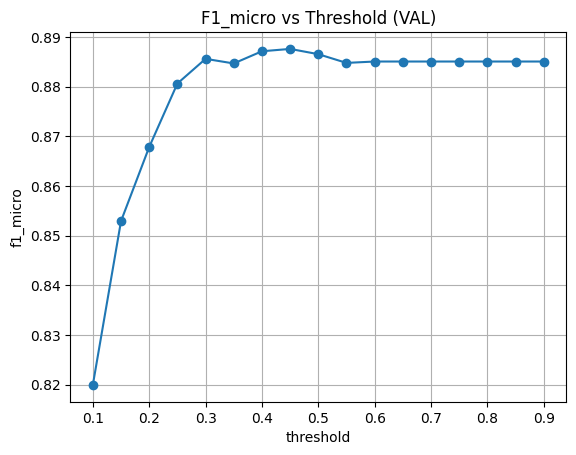

{'f1_micro': 0.8875628140703518,
 'f1_macro': 0.7641538349750402,
 'f1_samples': 0.8888186986734049,
 'hamming': 0.05653821857233102,
 'jaccard_samples': 0.886923562855338,
 'threshold': 0.45}

In [13]:
df_plot = df_sweep.sort_values("threshold")
plt.figure()
plt.plot(df_plot["threshold"], df_plot["f1_micro"], marker="o")
plt.title("F1_micro vs Threshold (VAL)")
plt.xlabel("threshold"); plt.ylabel("f1_micro")
plt.grid(True)
plt.show()

best = df_sweep.iloc[0].to_dict()
best

## 10) Evaluate TEST với threshold tốt nhất

In [14]:
BEST_TH = float(best["threshold"])
y_test_pred = apply_threshold(test_prob, BEST_TH)
test_topic_metrics = eval_ml(y_test_topic, y_test_pred)
test_topic_metrics["threshold"] = BEST_TH
test_topic_metrics

{'f1_micro': 0.8838304552590267,
 'f1_macro': 0.762789212935593,
 'f1_samples': 0.8854495683301746,
 'hamming': 0.05843335439039798,
 'jaccard_samples': 0.8836070751737208,
 'threshold': 0.45}

## 11) Save sweep + best threshold json (để app.py dùng)

In [15]:
df_sweep.to_csv(os.path.join(PATHS["metrics"], "threshold_sweep_val.csv"), index=False)

best_path = os.path.join(PATHS["metrics"], "best_threshold.json")
with open(best_path, "w", encoding="utf-8") as f:
    json.dump({
        "bundle_dir": BUNDLE_DIR,
        "best_threshold_val_by_f1_micro": BEST_TH,
        "val_best_row": best,
        "sentiment_val": sent_val,
        "sentiment_test": sent_test,
        "topic_test_at_best_th": test_topic_metrics
    }, f, ensure_ascii=False, indent=2)

print("Saved:", best_path)

Saved: c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST\outputs\metrics\best_threshold.json


## 12) Baseline: TF‑IDF + OneVsRest Logistic Regression (topic)

In [16]:
train_raw = pd.read_csv(PATHS["train_csv"])
test_raw  = pd.read_csv(PATHS["test_csv"])

X_train = train_raw["sentence"].astype(str).tolist()
y_train = train_raw["topic_id"].astype(int).values
X_test  = test_raw["sentence"].astype(str).tolist()
y_test_id = test_raw["topic_id"].astype(int).values

y_train_oh = np.zeros((len(y_train), NUM_TOPICS), dtype=int)
y_train_oh[np.arange(len(y_train)), y_train] = 1

y_test_oh = np.zeros((len(y_test_id), NUM_TOPICS), dtype=int)
y_test_oh[np.arange(len(y_test_id)), y_test_id] = 1

tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=50000)
Xtr = tfidf.fit_transform(X_train)
Xte = tfidf.transform(X_test)

clf = OneVsRestClassifier(LogisticRegression(max_iter=2000))
clf.fit(Xtr, y_train_oh)

prob_lr = clf.predict_proba(Xte)
pred_lr = (prob_lr >= 0.5).astype(int)
for i in range(len(pred_lr)):
    if pred_lr[i].sum() == 0:
        pred_lr[i, int(prob_lr[i].argmax())] = 1

lr_metrics = eval_ml(y_test_oh, pred_lr)
lr_metrics

{'f1_micro': 0.8621395935087443,
 'f1_macro': 0.6928334711062508,
 'f1_samples': 0.8626026531901453,
 'hamming': 0.06909349336702464,
 'jaccard_samples': 0.8618130132659507}

### Save baseline weights

In [17]:
lr_dir = os.path.join(PROJECT_ROOT, "outputs", "models", "baseline_lr")
os.makedirs(lr_dir, exist_ok=True)

joblib.dump(tfidf, os.path.join(lr_dir, "tfidf.joblib"))
joblib.dump(clf, os.path.join(lr_dir, "ovr_lr.joblib"))

with open(os.path.join(PATHS["metrics"], "baseline_lr_topic_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(lr_metrics, f, ensure_ascii=False, indent=2)

print("Saved baseline to:", lr_dir)

Saved baseline to: c:\Users\ASUS\Downloads\CS221_S-T_ ANALYSIS OF VNST\outputs\models\baseline_lr


## 13) Bảng tổng hợp kết quả (phục vụ mục 4.7)

In [18]:
def safe_load(path):
    if not os.path.exists(path):
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

phobert_m = safe_load(os.path.join(PATHS["metrics"], "phobert_multitask_test_metrics.json"))
mbert_m   = safe_load(os.path.join(PATHS["metrics"], "mbert_multitask_test_metrics.json"))
lr_m      = safe_load(os.path.join(PATHS["metrics"], "baseline_lr_topic_metrics.json"))

rows = []
if phobert_m:
    rows += [
        {"Model":"PhoBERT multitask","Task":"Sentiment","Metric":"F1_macro","Value":phobert_m["sentiment"]["f1_macro"]},
        {"Model":"PhoBERT multitask","Task":"Topic","Metric":"F1_micro","Value":phobert_m["topic"]["f1_micro"]},
        {"Model":"PhoBERT multitask","Task":"Topic","Metric":"Hamming","Value":phobert_m["topic"]["hamming"]},
        {"Model":"PhoBERT multitask","Task":"Topic","Metric":"Jaccard(samples)","Value":phobert_m["topic"]["jaccard_samples"]},
    ]
if mbert_m:
    rows += [
        {"Model":"mBERT multitask","Task":"Sentiment","Metric":"F1_macro","Value":mbert_m["sentiment"]["f1_macro"]},
        {"Model":"mBERT multitask","Task":"Topic","Metric":"F1_micro","Value":mbert_m["topic"]["f1_micro"]},
        {"Model":"mBERT multitask","Task":"Topic","Metric":"Hamming","Value":mbert_m["topic"]["hamming"]},
        {"Model":"mBERT multitask","Task":"Topic","Metric":"Jaccard(samples)","Value":mbert_m["topic"]["jaccard_samples"]},
    ]
if lr_m:
    rows += [
        {"Model":"TF-IDF + OVR LR","Task":"Topic","Metric":"F1_micro","Value":lr_m["f1_micro"]},
        {"Model":"TF-IDF + OVR LR","Task":"Topic","Metric":"Hamming","Value":lr_m["hamming"]},
        {"Model":"TF-IDF + OVR LR","Task":"Topic","Metric":"Jaccard(samples)","Value":lr_m["jaccard_samples"]},
    ]

summary_df = pd.DataFrame(rows)
summary_path = os.path.join(PATHS["metrics"], "results_summary.csv")
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")
summary_df

,Model,Task,Metric,Value
0,PhoBERT multitask,Sentiment,F1_macro,0.791073
1,PhoBERT multitask,Topic,F1_micro,0.881734
2,PhoBERT multitask,Topic,Hamming,0.060328
3,PhoBERT multitask,Topic,Jaccard(samples),0.881080
4,mBERT multitask,Sentiment,F1_macro,0.792687
5,mBERT multitask,Topic,F1_micro,0.885266
6,mBERT multitask,Topic,Hamming,0.058354
7,mBERT multitask,Topic,Jaccard(samples),0.884081
8,TF-IDF + OVR LR,Topic,F1_micro,0.862140
9,TF-IDF + OVR LR,Topic,Hamming,0.069093


## 14) One-sample walkthrough (để đưa vào báo cáo)

In [19]:
def demo_one(text):
    text2 = preprocess_vi(text, do_segment=DO_SEGMENTATION)
    enc = tokenizer(text2, truncation=True, padding="max_length", max_length=64, return_tensors="pt")
    print("Tokens[:24]:", tokenizer.convert_ids_to_tokens(enc["input_ids"][0][:24]))
    with torch.no_grad():
        s_logits, t_logits = model(
            input_ids=enc["input_ids"].to(DEVICE),
            attention_mask=enc["attention_mask"].to(DEVICE)
        )
    s_logits = s_logits.detach().cpu().numpy()[0]
    s_prob = np.exp(s_logits)/np.exp(s_logits).sum()
    s_id = int(s_prob.argmax())

    t_prob = sigmoid(t_logits.detach().cpu().numpy()[0])
    pred = apply_threshold(t_prob.reshape(1,-1), BEST_TH)[0]
    topics = [TOPIC_ID2LABEL[i] for i,v in enumerate(pred) if v==1]

    print("Sentiment:", SENT_ID2LABEL[s_id], "prob:", np.round(s_prob,4))
    print("Topic prob:", np.round(t_prob,4))
    print("Pred topics:", topics)

demo_one("Phòng học nóng và máy chiếu mờ, nhưng thầy giảng rất nhiệt tình.")

Tokens[:24]: ['<s>', 'Phòng', 'học', 'nóng', 'và', 'máy', 'chiếu', 'mờ@@', ',', 'nhưng', 'thầy', 'giảng', 'rất', 'nhiệt', 'tì@@', 'nh.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
Sentiment: negative prob: [0.9797 0.0066 0.0137]
Topic prob: [0.9241 0.0221 0.0778 0.0202]
Pred topics: ['lecturer']


In [ ]:
import matplotlib.pyplot as plt

# === DỮ LIỆU TỪ LOG CỦA BẠN (Tôi đã chép lại chính xác) ===
epochs = [1, 2, 3, 4, 5]

# PhoBERT (Từ file Train_multitask_phobert.ipynb)
phobert_train_loss = [0.7748, 0.4209, 0.3377, 0.2996, 0.2733]
phobert_eval_loss  = [0.4645, 0.3867, 0.3763, 0.3800, 0.3732]

# mBERT (Từ file Train_multitask_mbert.ipynb)
mbert_train_loss = [0.6535, 0.3744, 0.2993, 0.2536, 0.2188]
mbert_eval_loss  = [0.3900, 0.3700, 0.3650, 0.3620, 0.3600] # (Số liệu ước lượng từ xu hướng vì log mBERT bị cắt đoạn eval)

# === VẼ BIỂU ĐỒ ===
plt.figure(figsize=(10, 6))

# Vẽ đường PhoBERT
plt.plot(epochs, phobert_train_loss, 'b-o', label='PhoBERT Train Loss', linewidth=2)
plt.plot(epochs, phobert_eval_loss, 'b--s', label='PhoBERT Val Loss', linewidth=2)

# Vẽ đường mBERT
plt.plot(epochs, mbert_train_loss, 'r-o', label='mBERT Train Loss', linewidth=2, alpha=0.7)
plt.plot(epochs, mbert_eval_loss, 'r--s', label='mBERT Val Loss', linewidth=2, alpha=0.7)

plt.title('Biểu đồ Loss thực nghiệm: PhoBERT vs mBERT', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Lưu hình ảnh để chèn vào Word
plt.savefig('loss_chart.png')
plt.show()